## Experiment No: 10
## Experiment Title: Ensemble Learning (Random Forest and Boosting) vs Baseline Model - Performance Comparison

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
np.random.seed(33)

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Step 2: Load the Dataset

In [5]:
df = pd.read_csv("anime_success_dataset.csv")

print("Dataset Loaded Successfully")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Loaded Successfully
Dataset Shape: (1800, 18)


,studio,primary_genre,genre_count,source_material,demographic,episodes,episode_length_min,animation_budget_tier,marketing_spend_tier,voice_cast_popularity,director_experience_years,studio_prior_hits,release_season,release_year,has_sequel_potential_arc,mal_rating,popularity_score,success_tier
0,Lerche,Sci-Fi,2,Manga,Seinen,13,24,Low,High,1.81,9.1,4,Fall,2024,0,6.02,59.0,Average
1,Doga Kobo,Adventure,3,Visual Novel,Shounen,12,24,High,Medium,4.24,8.5,8,Summer,2021,0,8.55,86.7,Hit
2,Bones,Sports,3,Manga,Shounen,25,24,Medium,Medium,6.40,12.7,10,Winter,2019,0,10.00,100.0,Hit
3,J.C.Staff,Supernatural,3,Manga,Shounen,13,24,Medium,Medium,4.02,7.8,7,Winter,2015,1,7.57,87.2,Hit
4,Pierrot,Mecha,3,Visual Novel,Shoujo,12,24,Low,Low,5.63,5.9,6,Winter,2017,0,4.77,38.2,Flop


### Step 3: Exploratory Data Analysis (EDA)

Success Tier Distribution:
╒════════════════╤═════════╤══════════════╕
│  Success Tier  │   Count │   Percentage │
╞════════════════╪═════════╪══════════════╡
│      Hit       │    1011 │        56.17 │
├────────────────┼─────────┼──────────────┤
│    Average     │     447 │        24.83 │
├────────────────┼─────────┼──────────────┤
│      Flop      │     342 │           19 │
╘════════════════╧═════════╧══════════════╛


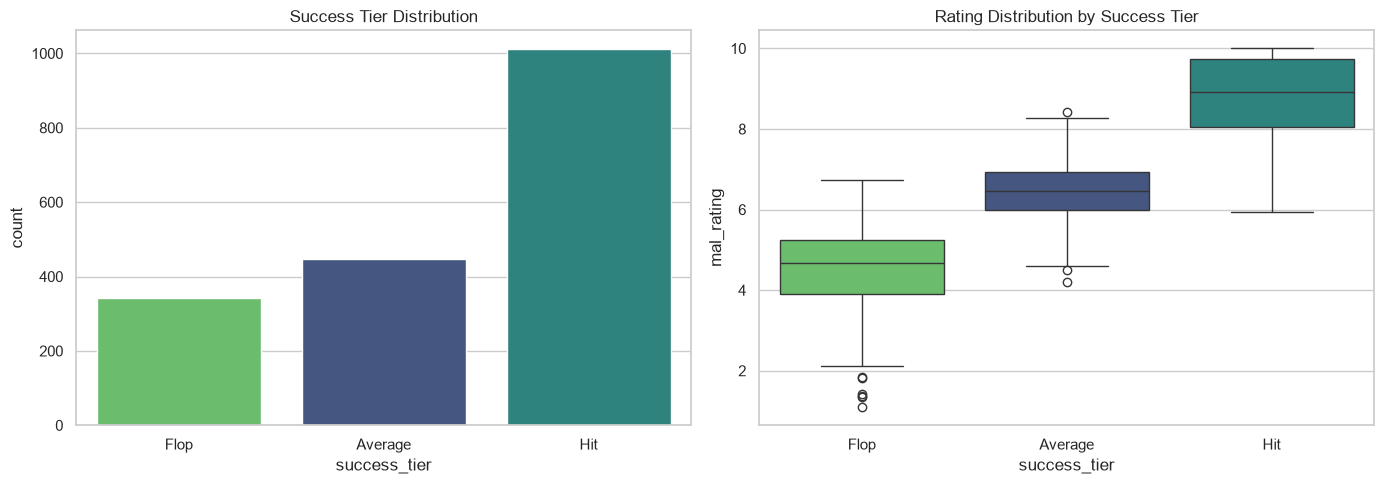

,count,mean,std,min,25%,50%,75%,max
genre_count,1800.0,1.991667,0.827835,1.0,1.0000,2.00,3.0000,3.0
episodes,1800.0,24.270000,19.910679,12.0,12.0000,13.00,25.0000,100.0
episode_length_min,1800.0,22.260000,4.226384,12.0,24.0000,24.00,24.0000,24.0
voice_cast_popularity,1800.0,5.162350,1.764511,1.0,3.9875,5.18,6.3825,10.0
director_experience_years,1800.0,8.100444,3.897479,0.0,5.5000,8.10,10.6000,21.1
studio_prior_hits,1800.0,6.433889,2.857962,0.0,4.0000,6.00,8.0000,21.0
release_year,1800.0,2019.436111,2.876043,2015.0,2017.0000,2019.00,2022.0000,2024.0
has_sequel_potential_arc,1800.0,0.451667,0.497797,0.0,0.0000,0.00,1.0000,1.0


In [7]:
print("Success Tier Distribution:")

tier_counts               = df["success_tier"].value_counts().reset_index()
tier_counts.columns       = ["Success Tier", "Count"]
tier_counts["Percentage"] = (tier_counts["Count"] / tier_counts["Count"].sum() * 100).round(2)

print(tabulate(
    tier_counts,
    headers="keys",
    tablefmt="fancy_grid",
    showindex=False,
    numalign="right",
    stralign="center"
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x="success_tier", data=df, order=["Flop", "Average", "Hit"], hue="success_tier", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Success Tier Distribution")

sns.boxplot(x="success_tier", y="mal_rating", data=df, order=["Flop", "Average", "Hit"], hue="success_tier", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Rating Distribution by Success Tier")

plt.tight_layout()
plt.show()

df.describe().T.head(8)

### Step 4: Feature and Target Selection


In [8]:
df_model = df.copy()
categorical_cols = ["studio", "primary_genre", "source_material", "demographic",
                     "animation_budget_tier", "marketing_spend_tier", "release_season"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

X = df_model.drop(columns=["success_tier", "mal_rating", "popularity_score"])
y = df_model["success_tier"]

print("Feature columns:", list(X.columns))
print("Feature matrix shape:", X.shape)

Feature columns: ['studio', 'primary_genre', 'genre_count', 'source_material', 'demographic', 'episodes', 'episode_length_min', 'animation_budget_tier', 'marketing_spend_tier', 'voice_cast_popularity', 'director_experience_years', 'studio_prior_hits', 'release_season', 'release_year', 'has_sequel_potential_arc']
Feature matrix shape: (1800, 15)


### Step 5: Split Data into Training and Testing Sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=33, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (1350, 15)
Testing set shape : (450, 15)


### Step 6: Train the Baseline Model - Single Decision Tree

In [10]:
baseline_model  = DecisionTreeClassifier(random_state=33)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("Baseline Decision Tree trained successfully")
print(f"Tree depth: {baseline_model.get_depth()}")

Baseline Decision Tree trained successfully
Tree depth: 16


### Step 7: Train Ensemble Model 1 - Random Forest (Bagging)

In [11]:
rf_model  = RandomForestClassifier(n_estimators=200, random_state=33)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully")
print(f"Number of trees: {rf_model.n_estimators}")

Random Forest trained successfully
Number of trees: 200


### Step 8: Train Ensemble Model 2 - Gradient Boosting (Boosting)

In [12]:
gb_model  = GradientBoostingClassifier(n_estimators=200, random_state=33)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting trained successfully")
print(f"Number of boosting stages: {gb_model.n_estimators}")

Gradient Boosting trained successfully
Number of boosting stages: 200


### Step 9: Compare Evaluation Metrics

In [13]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1-Score": f1_score(y_true, y_pred, average="macro")
    }

comparison_df = pd.DataFrame({
    "Decision Tree (Baseline)": get_metrics(y_test, y_pred_baseline),
    "Random Forest (Bagging)": get_metrics(y_test, y_pred_rf),
    "Gradient Boosting": get_metrics(y_test, y_pred_gb)
}).T

comparison_df

,Accuracy,Precision,Recall,F1-Score
Decision Tree (Baseline),0.493333,0.438865,0.438136,0.436659
Random Forest (Bagging),0.620000,0.540057,0.480061,0.481543
Gradient Boosting,0.628889,0.541587,0.533166,0.533004


### Step 10: Confusion Matrices for Each Model

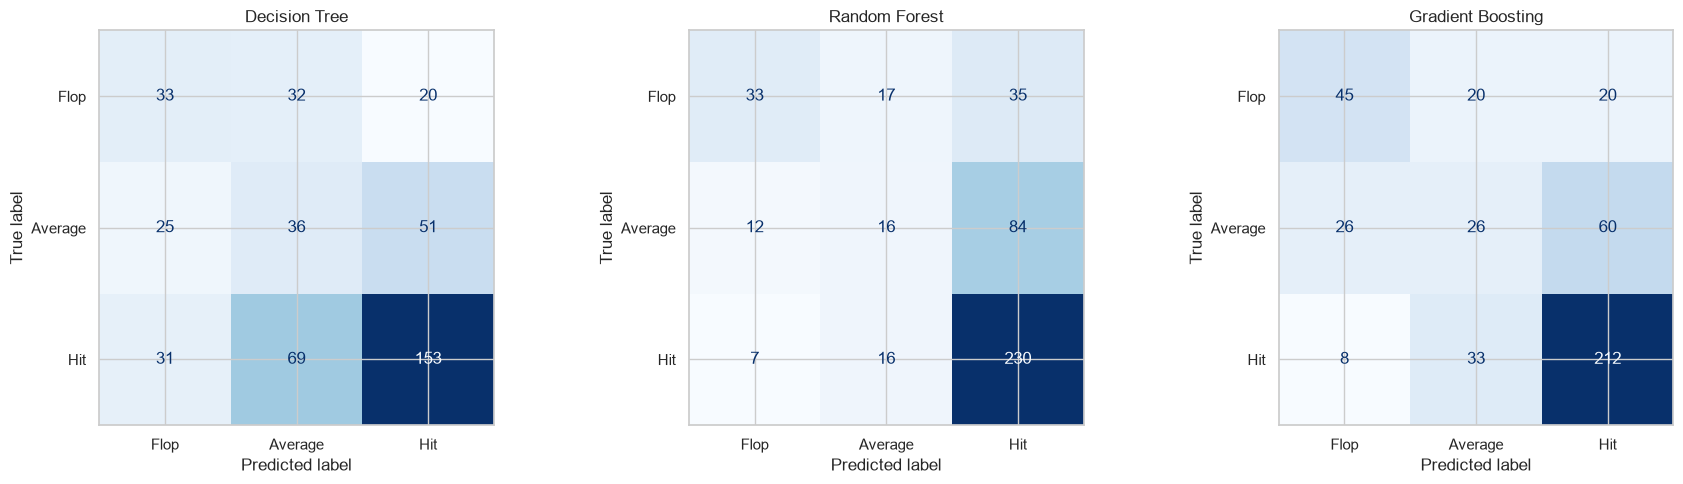

In [14]:
fig, axes    = plt.subplots(1, 3, figsize=(18, 5))
labels_order = ["Flop", "Average", "Hit"]

for ax, (name, preds) in zip(axes, [("Decision Tree", y_pred_baseline),
                                     ("Random Forest", y_pred_rf),
                                     ("Gradient Boosting", y_pred_gb)]):
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Step 11: Feature Importance Comparison (Baseline vs Random Forest)

Top 10 Most Important Features (sorted by Random Forest):

╒════╤═══════════════════════════╤═════════════════╤═════════════════╤═════════════════════╕
│    │ Feature                   │   Decision Tree │   Random Forest │   Gradient Boosting │
╞════╪═══════════════════════════╪═════════════════╪═════════════════╪═════════════════════╡
│  9 │ voice_cast_popularity     │       0.170897  │       0.162443  │           0.222205  │
├────┼───────────────────────────┼─────────────────┼─────────────────┼─────────────────────┤
│ 11 │ studio_prior_hits         │       0.12937   │       0.125908  │           0.179458  │
├────┼───────────────────────────┼─────────────────┼─────────────────┼─────────────────────┤
│  0 │ studio                    │       0.125301  │       0.108931  │           0.196829  │
├────┼───────────────────────────┼─────────────────┼─────────────────┼─────────────────────┤
│ 10 │ director_experience_years │       0.117536  │       0.105036  │           0.0775835 │
├────┼─────

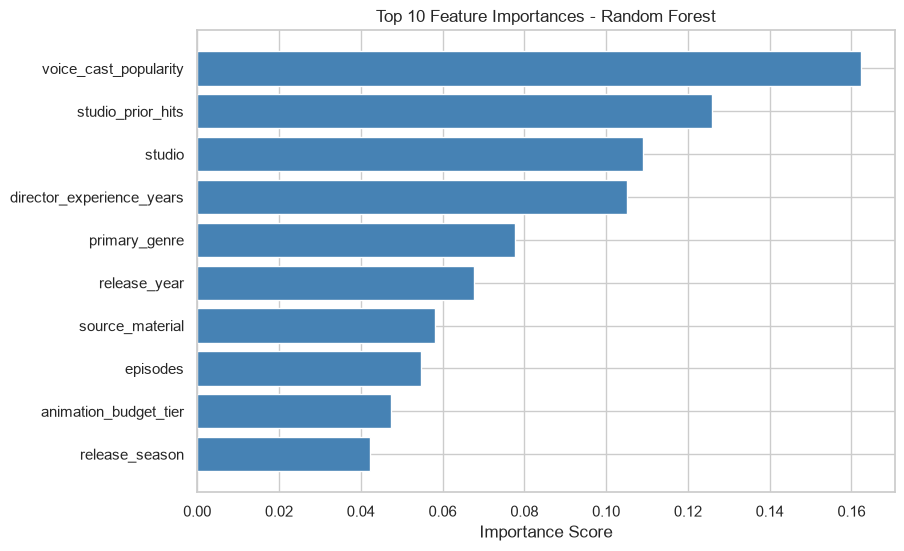

In [15]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Decision Tree": baseline_model.feature_importances_,
    "Random Forest": rf_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_
}).sort_values(by="Random Forest", ascending=False).head(10)

print("Top 10 Most Important Features (sorted by Random Forest):\n")
print(tabulate(importance_df, headers="keys", tablefmt="fancy_grid"))

plt.figure(figsize=(9, 6))
plt.barh(importance_df["Feature"], importance_df["Random Forest"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()

### Step 12: Final Output

In [16]:
print("Experiment Completed Successfully")
print("\nFinal Model Comparison:")
print(tabulate(comparison_df, headers="keys", tablefmt="fancy_grid"))

best_model_name = comparison_df["Accuracy"].idxmax()
print(f"\nBest performing model: {best_model_name} (Accuracy = {comparison_df['Accuracy'].max():.4f})")

Experiment Completed Successfully

Final Model Comparison:
╒══════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│                          │   Accuracy │   Precision │   Recall │   F1-Score │
╞══════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Decision Tree (Baseline) │   0.493333 │    0.438865 │ 0.438136 │   0.436659 │
├──────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Random Forest (Bagging)  │   0.62     │    0.540057 │ 0.480061 │   0.481543 │
├──────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Gradient Boosting        │   0.628889 │    0.541587 │ 0.533166 │   0.533004 │
╘══════════════════════════╧════════════╧═════════════╧══════════╧════════════╛

Best performing model: Gradient Boosting (Accuracy = 0.6289)
